In [1]:
# Data manipulation
import pandas as pd
import numpy as np


# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

# warning management library
import warnings

# Text Mining
import nltk
nltk.download('punkt')
from wordcloud import WordCloud
from collections import Counter
nltk.download('stopwords')
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('punkt_tab')

# Machine learning
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer

# Similarity metrics
from sklearn.metrics.pairwise import cosine_similarity as cossim

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\smazo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\smazo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\smazo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\smazo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
warnings.filterwarnings('ignore')
sns.set()
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

### 1. Loading of file movies_info.csv and selecting relevant columns

In [3]:
titles = pd.read_csv("../Transformed_Data/movies_info.csv", nrows = 1000)
#https://developer.imdb.com/non-commercial-datasets/

In [4]:
titles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   tconst         1000 non-null   object
 1   primaryTitle   1000 non-null   object
 2   genres         1000 non-null   object
 3   imdb_id        1000 non-null   object
 4   plot_synopsis  1000 non-null   object
 5   tags           1000 non-null   object
dtypes: object(6)
memory usage: 47.0+ KB


In [5]:
titles = titles[["primaryTitle", "genres", "plot_synopsis", "tags"]]
titles.head()

,primaryTitle,genres,plot_synopsis,tags
0,The House of the Devil,Horror Short,The film opens with a large bat flying into a ...,paranormal gothic
1,Beauty and the Beast,Family Fantasy Romance,A widower merchant lives in a mansion with his...,fantasy
2,Cinderella,Drama Family Fantasy,"A prologue in front of the curtain, suppressed...",fantasy
3,A Trip to the Moon,Adventure Comedy Fantasy,"At a meeting of the Astronomic Club, its presi...",psychedelic satire
4,The Land Beyond the Sunset,Drama Fantasy Short,Joe is an impoverished New York newsboy who li...,fantasy storytelling


In [6]:
titles.rename(columns={"primaryTitle": "title", "plot_synopsis": "synopsis"}, inplace=True)
titles.head()


,title,genres,synopsis,tags
0,The House of the Devil,Horror Short,The film opens with a large bat flying into a ...,paranormal gothic
1,Beauty and the Beast,Family Fantasy Romance,A widower merchant lives in a mansion with his...,fantasy
2,Cinderella,Drama Family Fantasy,"A prologue in front of the curtain, suppressed...",fantasy
3,A Trip to the Moon,Adventure Comedy Fantasy,"At a meeting of the Astronomic Club, its presi...",psychedelic satire
4,The Land Beyond the Sunset,Drama Fantasy Short,Joe is an impoverished New York newsboy who li...,fantasy storytelling


In [7]:
titles.drop_duplicates(subset="title",inplace=True)
titles.shape

(972, 4)

### 2. Starting Natural Language Processing

#### 2.1 Lemmatization and Tokenization functions

In [8]:
# list of french stopwords : https://www.ranks.nl/stopwords/french
french_stopwords = ["alors","au","aucun","aussi","autre","avant","avec","avoir","bon","car","ce","cela","ces","ceux","chaque","ci",
                    "comme","comment","dans","des","du",
"dedans","dehors","depuis","devrait","doit","donc","début", "de","elle","elles","en","encore","essai","est","et","eu","fait","faites",
"fois","font","hors","ici","il","ils","je","juste",
"la","le","les","leur","là","ma","maintenant","mais","mes","mien","moins","mon","mot","même","ni","notre","nous","ou","où","par",
"parce","pas","peut","peu","plupart","pour","pourquoi",
"quand","que","quel","quelle","quelles","quels","qui","sa","sans","ses","seulement","si","sien","son","sont","sous","soyez","sur",
"ta","tandis","tellement","tels","tes","ton","tous",
"tout","trop","très","tu","voient","vont","votre","vous","vu","ça","étaient","état","étions","été","être", "un"]

In [9]:
# creating a list of stopwords for a specific text : with text most common words, and with french end english typical stopwords list
def stopwords_list(text,sw_nb):
    # Lemmatization
    text=text.lower()
    lemmatizer = WordNetLemmatizer()
    text=lemmatizer.lemmatize(text)
    
    # Tokenization
    words_list=nltk.word_tokenize(text)
    words_list= [word for word in words_list if word.isalnum()]
    
    # Suppress digits
    words_list=[w for w in words_list if w.isalpha()]
    
    # wordcount and stopwords
    word_counts = Counter(words_list)
    stopwords_list=[count[0] for count in word_counts.most_common(sw_nb)]
    
    sw = set()
    sw.update(stopwords_list)
    sw.update(tuple(nltk.corpus.stopwords.words('english')))
    sw=list(sw)
    # adding french stopwords
    for fsw in french_stopwords:
        sw.append(fsw)
    return sw

In [10]:
# Text lemmatization and tokenization
def tokenize_text(text):
    # Lemmatization
    text=text.lower()
    lemmatizer = WordNetLemmatizer()
    text=lemmatizer.lemmatize(text)
    
    # Tokenization
    words_list=nltk.word_tokenize(text)
    words_list= [word for word in words_list if word.isalnum()]
    
    # Suppress digits
    words_list=[lemmatizer.lemmatize(w) for w in words_list if w.isalpha()]
    return words_list

In [11]:
# definition of a wordcloud function to have a small visualisation
def word_cloud(words_list):
    wordcloud=WordCloud()
    sentence=' '.join(words_list)
    wordcloud.generate(sentence)
    # create a figure
    fig, ax = plt.subplots(1,1, figsize = (9,6))
    # add interpolation = bilinear to smooth things out
    plt.imshow(wordcloud, interpolation='bilinear')
    # and remove the axis
    plt.axis("off")

#### 2.2 Text pre-processing

In [12]:
text = (titles["title"] + " " + titles["synopsis"] + " ").sum()

In [13]:
text[:100]

'The House of the Devil The film opens with a large bat flying into a medieval castle. The bat circle'

In [14]:
sw=stopwords_list(text,10)

In [15]:
sw[:20]

['ma',
 'ourselves',
 'very',
 's',
 'while',
 'does',
 'was',
 "weren't",
 'through',
 'do',
 'your',
 'we',
 'so',
 "they've",
 'been',
 "you'd",
 'by',
 "mustn't",
 "haven't",
 "you're"]

In [16]:
text = (titles.loc[:,"title"] + " " +titles.loc[:,"synopsis"] + " " + titles.loc[:,"genres"] + " " + titles.loc[:,"tags"] + " ").sum()
words_list = tokenize_text(text)

In [17]:
words_list_wo_sw=[w for w in words_list if w not in sw]

In [18]:
words_list_wo_sw[:20]

['house',
 'devil',
 'film',
 'open',
 'large',
 'bat',
 'flying',
 'medieval',
 'castle',
 'bat',
 'circle',
 'room',
 'suddenly',
 'changing',
 'mephistopheles',
 'incarnation',
 'devil',
 'mephistopheles',
 'produce',
 'cauldron']

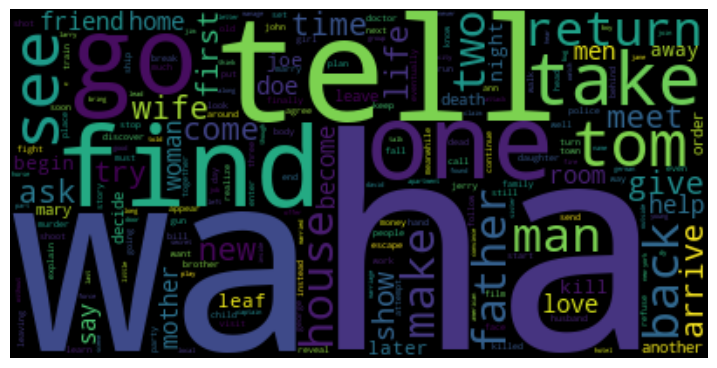

In [19]:
word_cloud(words_list_wo_sw)

#### 2.3 TF-IDF

In [20]:
tfidf = TfidfVectorizer(tokenizer=tokenize_text,stop_words=sw)

In [21]:
words_tfidf = tfidf.fit_transform((titles.iloc[:,0] + " " + titles.iloc[:,1] + " "+ titles.iloc[:,2] + " " + titles.iloc[:,3] + " "))

In [22]:
words_tfidf.shape

(972, 24399)

### 3. Recommandations using cosine similarity

#### 3.1 recommendation function

In [23]:
cossim_matrix = cossim(words_tfidf,words_tfidf)

In [24]:
cossim_matrix.shape

(972, 972)

<Axes: >

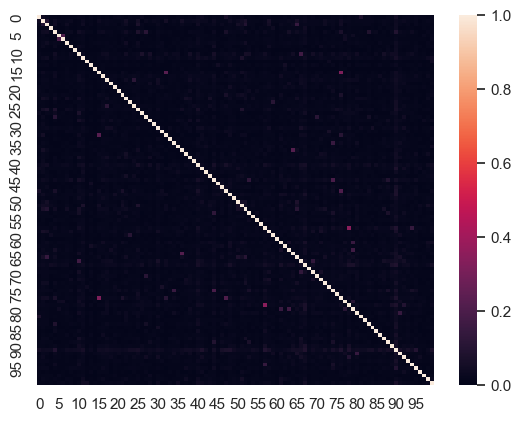

In [25]:
sns.heatmap(cossim_matrix[:100, :100])

In [26]:
# generate serie with the index of each movie
indices = pd.Series(titles.index, index=titles['title'].apply(lambda x: x.lower())) #.drop_duplicates()

In [27]:
indices[:10]

title
the house of the devil        0
beauty and the beast          1
cinderella                    2
a trip to the moon            3
the land beyond the sunset    4
antony and cleopatra          5
julius caesar                 6
a midsummer night's dream     7
frankenstein                  8
the fugitive                  9
dtype: int64

In [28]:
def get_reco(title, cosine_sim=cossim_matrix):
    # Get the index of the movie that matches the title
    title = title.lower()
    idx = indices[title]

    # Get the pairwsie similarity scores of all movies with that movie
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort the movies based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the scores of the 10 most similar movies
    sim_scores = sim_scores[1:11]

    # Get the movie indices
    movie_indices = [i[0] for i in sim_scores]

    # Return the top 10 most similar movies
    return titles[['title', "genres"]].iloc[movie_indices]

#### 3.2 Examples of recommandation

In [29]:
# recommandation for the first movie
print("first movie title: "+titles['title'].iloc[0] )
print("first movie genres: "+titles['genres'].iloc[0] )
get_reco(titles['title'].iloc[0])

first movie title: The House of the Devil
first movie genres: Horror Short


,title,genres
322,The Ghost Rider,Drama Western
127,The Bat Whispers,Crime Drama Horror
769,The Devil's Envoys,Drama Fantasy Romance
590,The Devil Bat,Horror Sci-Fi
120,The Skeleton Dance,Animation Comedy Family
85,Faust,Drama Fantasy Horror
321,Frisco Kid,Action Adventure Crime
123,Un chien andalou,Fantasy Horror Short
50,Häxan,Documentary Fantasy Horror
359,Bottles,Animation Family Fantasy


In [33]:
movie_index = 2
def print_reco(movie_index = 0):
    print("first movie title: "+titles['title'].iloc[movie_index] )
    print("first movie genres: "+titles['genres'].iloc[movie_index] )
    print(get_reco(titles['title'].iloc[movie_index]))

print_reco(2)

first movie title: Cinderella
first movie genres: Drama Family Fantasy
                         title                      genres
69         The Thief of Bagdad    Adventure Family Fantasy
985     Swing Shift Cinderella  Adventure Animation Comedy
442  The Prince and the Pauper      Adventure Drama Family
335                 Music Land     Animation Comedy Family
55                  Robin Hood    Adventure Family Romance
1         Beauty and the Beast      Family Fantasy Romance
712      The Bowling Alley-Cat     Animation Comedy Family
986                Tee for Two     Animation Comedy Family
806                 Happy Land           Drama Romance War
178             The Blue Light       Drama Fantasy Mystery
